<a href="https://colab.research.google.com/github/mariabenx138-cloud/CHECKPOINT_02_SERS_1ccpj/blob/main/Aula_APIs_Energia_Renovavel_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Avaliação — APIs de energia renovável e aprendizado de máquina

Consulte duas APIs públicas, organize os dados e resolva **duas tarefas**: classificar a fonte de empreendimentos da ANEEL e estimar a radiação solar em Petrolina (PE). Em **cada tarefa**, treine e compare **três algoritmos diferentes**. Este notebook fornece a consulta às APIs e os arquivos de dados; **você implementará a análise e os modelos**.

**Entrega:** um único link para um repositório público no GitHub com notebook executável, arquivos de dados, README e resultados. As instruções completas estão ao final e no enunciado separado.

## O que é recebido da API?

Uma requisição HTTP `GET` pede dados a uma URL. Os parâmetros identificam o recurso, o período e as variáveis. A resposta é **JSON**: um objeto com chaves e valores. Nas duas consultas desta avaliação, o acesso público **não exige login, token ou chave de API**. Se outra API exigir credenciais, não as publique no repositório.

Este código usa somente `json`, `urllib` e `csv`, bibliotecas que vêm com Python. `csv` serve apenas para exportar os dados recebidos; os imports para análise, tabelas, gráficos e ML são parte da sua implementação.

In [ ]:
import json
import urllib.parse
import urllib.request
import csv

In [ ]:
# Manipulação de dados e gráficos
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Separação treino/teste e padronização
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Algoritmos de CLASSIFICAÇÃO
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

# Algoritmos de REGRESSÃO
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Métricas de classificação
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)
# Métricas de regressão
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

SEMENTE = 42   # semente fixa: garante resultados reprodutíveis
sns.set_theme(style="whitegrid")

A função a seguir monta a URL, abre a conexão, verifica o status HTTP e converte o JSON. Se houver falha na rede ou na API, exibe uma mensagem de erro.

In [ ]:
def consultar_api(endereco, parametros):
    url = endereco + "?" + urllib.parse.urlencode(parametros)
    try:
        with urllib.request.urlopen(url, timeout=30) as resposta:
            return json.load(resposta)
    except Exception as erro:
        raise RuntimeError(f"Não foi possível consultar a API: {erro}") from erro

# Tarefa 1 — Classificação (ANEEL)

**Pergunta:** a partir da potência e da localização de um empreendimento, é possível classificar sua fonte como **Solar, Eólica ou Hidráulica**?

A fonte é uma **categoria**: o problema é de classificação. O conjunto [SIGA da ANEEL](https://dadosabertos.aneel.gov.br/dataset/siga-sistema-de-informacoes-de-geracao-da-aneel) registra empreendimentos em várias fases. Usamos `UFV` (solar fotovoltaica), `EOL` (eólica) e três categorias hidráulicas: `UHE`, `PCH`, `CGH`. Estas três últimas formarão uma única classe, *Hidráulica*. A tarefa trata da **categoria do cadastro**, não da quantidade de energia gerada.

### Atributos originais da resposta

| Campo da API | Significado | Uso na tarefa |
|---|---|---|
| `SigTipoGeracao` | Sigla do tipo de geração (`UFV`, `EOL`, `UHE`, `PCH`, `CGH`) | Origina o alvo `fonte`; **não entra em X** |
| `MdaPotenciaOutorgadaKw` | Potência outorgada do empreendimento, em quilowatts (kW) | Entrada `potencia_kw`; potência nominal autorizada, não energia produzida |
| `NumCoordNEmpreendimento` | Latitude aproximada do empreendimento, em graus decimais | Entrada `latitude` |
| `NumCoordEEmpreendimento` | Longitude aproximada do empreendimento, em graus decimais | Entrada `longitude` |
| `CodCEG`, `NomEmpreendimento` e campos de combustível | Código, nome e descrição associados ao empreendimento e à fonte | **Não usar como entradas**: podem revelar a classe |

A resposta CKAN contém `success` e `result`; dentro de `result`, `records` são as linhas, `fields` descrevem as colunas e `total` indica o total encontrado para o filtro. O CSV final terá **três atributos numéricos e a classe**. Quantidades consultadas têm limite por tipo e não representam a participação de cada fonte na matriz brasileira.

### 1. Consultar a ANEEL

O recurso SIGA é acessado pela API pública CKAN/DataStore. `resource_id` aponta para o conjunto; `filters` seleciona uma sigla; `limit` limita o retorno de cada pedido. Não há etapa de autenticação para esta consulta pública.

In [ ]:
URL_ANEEL = "https://dadosabertos.aneel.gov.br/api/3/action/datastore_search"
ID_RECURSO = "11ec447d-698d-4ab8-977f-b424d5deee6a"
SIGLAS = ["UFV", "EOL", "UHE", "PCH", "CGH"]
print("API ANEEL: consulta pública, sem token")

API ANEEL: consulta pública, sem token


In [ ]:
registros_aneel = []
for sigla in SIGLAS:
    parametros = {
        "resource_id": ID_RECURSO,
        "filters": json.dumps({"SigTipoGeracao": sigla}),
        "limit": 1200,
    }
    resposta = consultar_api(URL_ANEEL, parametros)
    if not resposta.get("success"):
        raise ValueError(f"Consulta da ANEEL falhou para {sigla}")
    linhas = resposta["result"]["records"]
    print(f"{sigla}: {len(linhas)} linhas recebidas")
    registros_aneel.extend(linhas)
print("Total de linhas recebidas:", len(registros_aneel))

UFV: 1200 linhas recebidas
EOL: 1200 linhas recebidas
UHE: 221 linhas recebidas
PCH: 537 linhas recebidas
CGH: 718 linhas recebidas
Total de linhas recebidas: 3876


### 2. Gerar o CSV para a tarefa

A API pode fornecer números como texto, inclusive com vírgula decimal. O tratamento abaixo converte esses valores, descarta linhas sem potência ou coordenadas e transforma as siglas em três classes. Cada linha do arquivo final representa **um empreendimento**. Confira a quantidade de exemplos por classe durante sua análise; se necessário, discuta o desequilíbrio entre classes.

In [ ]:
def numero(valor):
    texto = str(valor).strip()
    if "," in texto:
        texto = texto.replace(".", "").replace(",", ".")
    try:
        return float(texto)
    except ValueError:
        return None

fontes = {"UFV": "Solar", "EOL": "Eólica", "UHE": "Hidráulica",
          "PCH": "Hidráulica", "CGH": "Hidráulica"}
linhas_classificacao = []
for registro in registros_aneel:
    potencia = numero(registro.get("MdaPotenciaOutorgadaKw"))
    latitude = numero(registro.get("NumCoordNEmpreendimento"))
    longitude = numero(registro.get("NumCoordEEmpreendimento"))
    fonte = fontes.get(registro.get("SigTipoGeracao"))
    if fonte and all(valor is not None for valor in (potencia, latitude, longitude)):
        linhas_classificacao.append([potencia, latitude, longitude, fonte])
if len(linhas_classificacao) < 90:
    raise ValueError("Poucos registros válidos: confira a resposta da ANEEL")
print("Linhas válidas:", len(linhas_classificacao))
print("Primeiro exemplo:", linhas_classificacao[0])

Linhas válidas: 3876
Primeiro exemplo: [20.48, -10.44277778, -64.15194444, 'Solar']


In [ ]:
with open("aneel_classificacao_orange.csv", "w", newline="", encoding="utf-8-sig") as arquivo:
    escritor = csv.writer(arquivo)
    escritor.writerow(["potencia_kw", "latitude", "longitude", "fonte"])
    escritor.writerows(linhas_classificacao)
print("Salvo: aneel_classificacao_orange.csv")

Salvo: aneel_classificacao_orange.csv


### O que você deve fazer — classificação

1. Carregue o CSV, confira os tipos das colunas, as contagens por classe, valores ausentes e distribuições relevantes. Explique `X` (três entradas) e `y` (`fonte`).
2. Faça uma divisão **estratificada** de treino/teste, por exemplo 80%/20%, com semente fixa. Ajustes de escala aprendidos dos dados devem ser feitos **somente com o treino**.
3. Escolha, justifique e treine **três classificadores diferentes** usando a mesma divisão. Eles **não estão importados nem implementados** neste notebook.
4. Compare Accuracy, Precision, Recall e F1. Declare o tipo de média usado nas métricas por classe (por exemplo, `macro`) e apresente a matriz de confusão.
5. Explique qual modelo escolheria, quais classes ele mais confunde e por que potência/localização podem não bastar para uma aplicação real. Não use `SigTipoGeracao`, nomes, CEG ou descrições da fonte como entradas.

**O que registrar:** tabela comparativa dos três algoritmos, gráfico(s) ou matriz de confusão e interpretação escrita.

In [ ]:
# Carregar o CSV
df1 = pd.read_csv('/content/aneel_classificacao_orange.csv')
df1.head(10)

,potencia_kw,latitude,longitude,fonte
0,20.48,-10.442778,-64.151944,Solar
1,5000.00,-6.003889,-40.274722,Solar
2,12.26,-23.557778,-46.734000,Solar
3,3.00,-23.558889,-46.735000,Solar
4,1.70,-23.493819,-46.845000,Solar
5,404.80,-12.945833,-38.417778,Solar
6,1082.00,-22.815833,-47.059167,Solar
7,1.70,-27.447981,-48.501745,Solar
8,1.04,-22.172160,-47.337620,Solar
9,30.87,-2.474278,-43.574217,Solar


In [ ]:
# Tipos das colunas e quantidade de linhas
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3876 entries, 0 to 3875
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   potencia_kw  3876 non-null   float64
 1   latitude     3876 non-null   float64
 2   longitude    3876 non-null   float64
 3   fonte        3876 non-null   object 
dtypes: float64(3), object(1)
memory usage: 121.3+ KB


In [ ]:
# Contagens das classes presentes na coluna
contagem = df1["fonte"].value_counts()
print(contagem)

fonte
Hidráulica    1476
Solar         1200
Eólica        1200
Name: count, dtype: int64


In [ ]:
# Valores ausentes e duplicados
print("Valores ausentes por coluna:")
print(df1.isnull().sum())

Valores ausentes por coluna:
potencia_kw    0
latitude       0
longitude      0
fonte          0
dtype: int64


In [ ]:
# Estatísticas descritivas das entradas, por classe
df1.groupby("fonte")[["potencia_kw", "latitude", "longitude"]].describe().T

fonte                     Eólica    Hidráulica          Solar
potencia_kw count    1200.000000  1.476000e+03    1200.000000
            mean    30782.769883  7.580916e+04   11679.386733
            std     13800.597800  4.864196e+05   18374.855154
            min         0.160000  9.900000e-01       0.260000
            25%     23100.000000  9.900000e+02       1.000000
            50%     29600.000000  4.000000e+03       1.000000
            75%     37200.000000  1.700000e+04   28880.000000
            max    105000.000000  1.123310e+07  137480.000000
latitude    count    1200.000000  1.476000e+03    1200.000000
            mean       -9.896436 -2.111301e+01      -5.136029
            std         7.529853  6.500423e+00       5.546914
            min       -33.722806 -3.078799e+01     -29.835550
            25%       -11.136206 -2.675362e+01      -6.924585
            50%        -7.986274 -2.203073e+01      -2.055540
            75%        -5.271434 -1.760462e+01      -1.831473
            max         0.000000  3.801667e+00       3.831392
longitude   count    1200.000000  1.476000e+03    1200.000000
            mean      -39.715921 -4.893246e+01     -49.188463
            std         7.231867  7.976908e+00       5.912291
            min       -55.930850 -6.464614e+01     -69.941389
            25%       -41.865407 -5.263224e+01     -53.067800
            50%       -40.692088 -5.041888e+01     -52.440865
            75%       -36.491659 -4.619944e+01     -44.881156
            max         0.000000  0.000000e+00     -35.235400

In [ ]:
X = df1[["potencia_kw", "latitude", "longitude"]]   # entradas
y = df1["fonte"]                                    # alvo
print("X:", X.shape, "| y:", y.shape)
X.head()

X: (3876, 3) | y: (3876,)


,potencia_kw,latitude,longitude
0,20.48,-10.442778,-64.151944
1,5000.00,-6.003889,-40.274722
2,12.26,-23.557778,-46.734000
3,3.00,-23.558889,-46.735000
4,1.70,-23.493819,-46.845000


In [ ]:
# Divisão estratificada
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=0.2, random_state=SEMENTE, stratify=y)

print(f"Total de registros para treino: {X_treino.shape[0]}")
print(f"Total de registros para teste:  {X_teste.shape[0]}")
print("\nProporção por classe (%):")
print(pd.DataFrame({"treino": y_treino.value_counts(normalize=True) * 100,
                    "teste": y_teste.value_counts(normalize=True) * 100}).round(1))

# Padronização aprendida SOMENTE no treino
escala1 = StandardScaler()
X_treino_esc = escala1.fit_transform(X_treino)
X_teste_esc = escala1.transform(X_teste)

Total de registros para treino: 3100
Total de registros para teste:  776

Proporção por classe (%):
            treino  teste
fonte                    
Hidráulica    38.1   38.1
Solar         31.0   30.9
Eólica        31.0   30.9


### Escolha e justificativa dos três classificadores

| Algoritmo | Por que foi escolhido | Cuidado |
|---|---|---|
| **Regressão Logística** | Modelo da Aula 06; simples, rápido e interpretável. Fronteiras **lineares**. | Precisa de dados padronizados; tem dificuldade se as classes se misturam de forma não linear. |
| **KNN (k vizinhos)** | Classifica pela classe dos vizinhos mais próximos: combina bem com **localização geográfica**. | Sensível à escala (por isso usamos dados padronizados) e ao valor de `k`. |
| **Random Forest** | Conjunto de árvores; captura **relações não lineares** e interações (ex.: "potência baixa **e** região X"). | Mais difícil de interpretar; pode super-ajustar sem limites. |

Os três usam **exatamente a mesma divisão** treino/teste.

In [ ]:
modelos_clf = {
    "Regressão Logística": LogisticRegression(max_iter=2000, class_weight="balanced", random_state=SEMENTE),
    "KNN (k=5)":           KNeighborsClassifier(n_neighbors=5),
    "Random Forest":       RandomForestClassifier(n_estimators=200, class_weight="balanced",
                                                  random_state=SEMENTE, n_jobs=-1),
}

resultados_clf = []
previsoes_clf = {}

for nome, modelo in modelos_clf.items():
    modelo.fit(X_treino_esc, y_treino)            # treina (Aula 06)
    y_prev = modelo.predict(X_teste_esc)          # prevê o teste
    previsoes_clf[nome] = y_prev
    resultados_clf.append({
        "Modelo": nome,
        "Accuracy":  accuracy_score(y_teste, y_prev),
        "Precision (macro)": precision_score(y_teste, y_prev, average="macro", zero_division=0),
        "Recall (macro)":    recall_score(y_teste, y_prev, average="macro", zero_division=0),
        "F1 (macro)":        f1_score(y_teste, y_prev, average="macro", zero_division=0),
    })

comparacao_clf = pd.DataFrame(resultados_clf).set_index("Modelo").round(4)
comparacao_clf

,Accuracy,Precision (macro),Recall (macro),F1 (macro)
Modelo,,,,
Regressão Logística,0.7964,0.8003,0.7968,0.7933
KNN (k=5),0.9652,0.9663,0.9636,0.9648
Random Forest,0.9742,0.9754,0.9727,0.9739


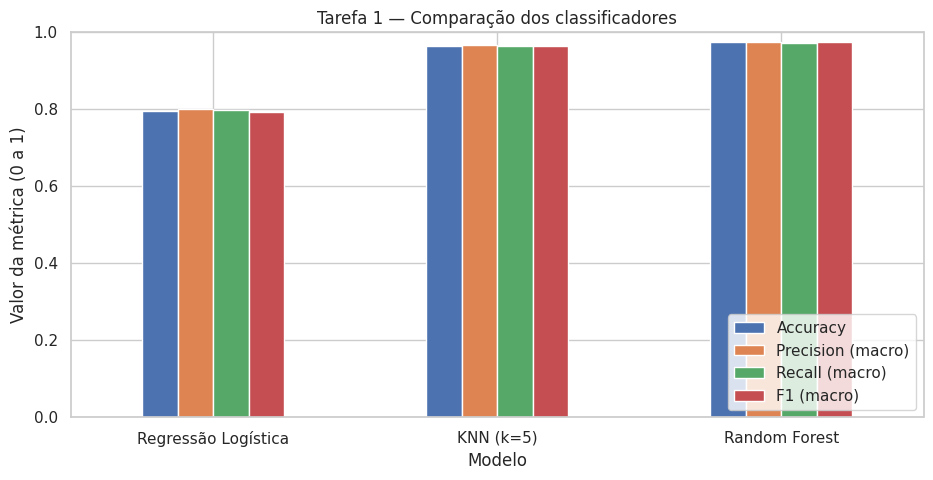

In [ ]:
# Comparação visual das métricas
comparacao_clf.plot(kind="bar", figsize=(11, 5), rot=0)
plt.title("Tarefa 1 — Comparação dos classificadores")
plt.ylabel("Valor da métrica (0 a 1)")
plt.ylim(0, 1)
plt.legend(loc="lower right")
plt.show()

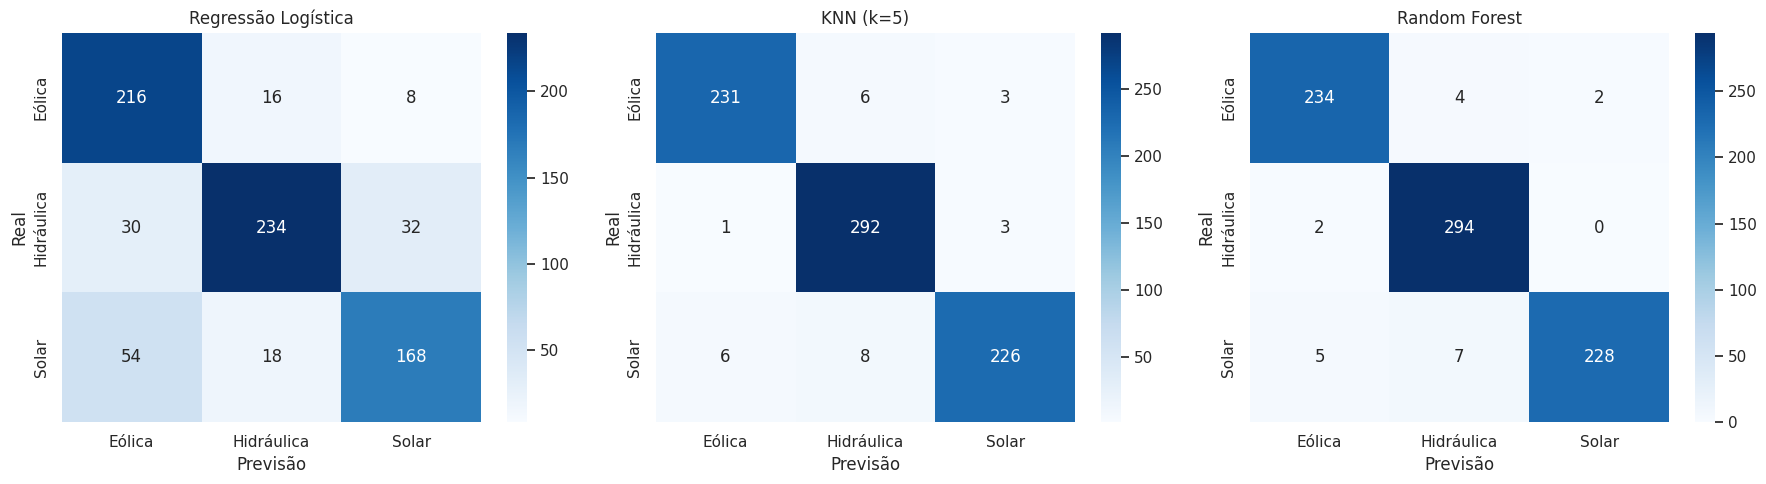

In [ ]:
# Matrizes de confusão dos três modelos
classes = sorted(y.unique())
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (nome, y_prev) in zip(axes, previsoes_clf.items()):
    mc = confusion_matrix(y_teste, y_prev, labels=classes)
    sns.heatmap(mc, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=classes, yticklabels=classes)
    ax.set_title(nome)
    ax.set_xlabel("Previsão"); ax.set_ylabel("Real")
plt.tight_layout()
plt.show()

In [ ]:
# Relatório por classe do melhor modelo (critério: maior F1 macro)
melhor_clf = comparacao_clf["F1 (macro)"].idxmax()
print(f"Melhor classificador (F1 macro): {melhor_clf}\n")
print(classification_report(y_teste, previsoes_clf[melhor_clf], zero_division=0))

# Par de classes mais confundido pelo melhor modelo
mc = confusion_matrix(y_teste, previsoes_clf[melhor_clf], labels=classes)
erros = [(mc[i, j], classes[i], classes[j])
         for i in range(len(classes)) for j in range(len(classes)) if i != j]
qtd, real, previsto = max(erros)
print(f"Maior confusão: {qtd} empreendimentos '{real}' foram previstos como '{previsto}'.")

Melhor classificador (F1 macro): Random Forest

              precision    recall  f1-score   support

      Eólica       0.97      0.97      0.97       240
  Hidráulica       0.96      0.99      0.98       296
       Solar       0.99      0.95      0.97       240

    accuracy                           0.97       776
   macro avg       0.98      0.97      0.97       776
weighted avg       0.97      0.97      0.97       776

Maior confusão: 7 empreendimentos 'Solar' foram previstos como 'Hidráulica'.


##Interpretação — Tarefa 1
**Qual modelo escolher?** O de maior F1 macro, considerando também o recall das classes menores. Se os resultados forem próximos, prefira o mais simples e explicável.

**Quais classes são mais confundidas?** As que apresentam características semelhantes, como pequenas usinas hidráulicas e solares, cujas faixas de potência podem se sobrepor.

**Por que potência e localização podem não bastar?** Porque não representam fatores naturais, como vento, radiação solar e vazão dos rios. Além disso, a potência autorizada não indica a geração real, as coordenadas podem ser aproximadas e a amostra pode não representar a realidade nacional. Empreendimentos próximos também podem gerar resultados artificialmente melhores durante a avaliação.

# Tarefa 2 — Regressão (Open-Meteo)

**Pergunta:** dadas as condições meteorológicas e a hora local em Petrolina (PE), qual é a radiação solar horizontal média naquela hora? A resposta é um **número**, então o problema é de regressão.

A API histórica do [Open-Meteo](https://open-meteo.com/en/docs/historical-weather-api) devolve dados horários para coordenadas e período escolhidos. Usamos **1º de abril a 30 de junho de 2025**, em horário local. São dados históricos estimados por modelos/reanálise, não leituras de um sensor particular. **Radiação em W/m² não equivale à energia em kWh nem à geração de um painel.**

### Parâmetros da requisição

| Parâmetro | Valor nesta avaliação | Significado |
|---|---|---|
| `latitude`, `longitude` | `-9.39`, `-40.50` | Coordenadas aproximadas de Petrolina (PE) |
| `start_date`, `end_date` | `2025-04-01`, `2025-06-30` | Período histórico consultado, inclusive as datas extremas |
| `timezone` | `America/Recife` | Faz `time` representar a hora local |
| `hourly` | Lista das cinco variáveis abaixo | Solicita valores horários em JSON |

### Atributos do conjunto de dados

| Campo da API → CSV | Significado e unidade | Uso na tarefa |
|---|---|---|
| `time` → `data_hora` | Data e hora local de cada registro | Ordenar e separar por tempo; não é entrada em X |
| `temperature_2m` → `temperatura_c` | Temperatura do ar a 2 m, em °C | Entrada |
| `relative_humidity_2m` → `umidade_pct` | Umidade relativa a 2 m, em % | Entrada |
| `cloud_cover` → `nuvens_pct` | Cobertura total de nuvens, em % | Entrada |
| `wind_speed_10m` → `vento_kmh` | Velocidade do vento a 10 m, em km/h | Entrada |
| `time` → `hora` | Hora local extraída da data, de 7 a 17 nesta amostra | Entrada |
| `shortwave_radiation` → `radiacao_w_m2` | Radiação solar global horizontal média da hora anterior, em W/m² | Alvo numérico `y`; **não entra em X** |

A resposta inclui `hourly` (listas dos valores, alinhadas por índice), `hourly_units` (unidades) e metadados da localização. Cada linha do CSV final representa **uma hora entre 7h e 17h**; esse recorte reduz o domínio de horas noturnas, mas não remove a importância da hora para a previsão.

### 3. Consultar o histórico meteorológico

A chamada usa GET, sem cadastro ou chave para esta consulta pública de uso educacional. Se `hourly` faltar, verifique datas e parâmetros.

In [ ]:
URL_METEO = "https://archive-api.open-meteo.com/v1/archive"
parametros_meteo = {
    "latitude": -9.39,
    "longitude": -40.50,
    "start_date": "2025-04-01",
    "end_date": "2025-06-30",
    "timezone": "America/Recife",
    "hourly": ",".join(["temperature_2m", "relative_humidity_2m",
                         "cloud_cover", "wind_speed_10m", "shortwave_radiation"]),
}
print("Open-Meteo: consulta pública, sem token")

Open-Meteo: consulta pública, sem token


In [ ]:
resposta_meteo = consultar_api(URL_METEO, parametros_meteo)
if "hourly" not in resposta_meteo:
    raise ValueError("Resposta sem a seção hourly")
horas_api = resposta_meteo["hourly"]
print("Campos recebidos:", list(horas_api))
print("Unidades informadas pela API:", resposta_meteo.get("hourly_units", {}))
print("Quantidade de horários:", len(horas_api["time"]))

Campos recebidos: ['time', 'temperature_2m', 'relative_humidity_2m', 'cloud_cover', 'wind_speed_10m', 'shortwave_radiation']
Unidades informadas pela API: {'time': 'iso8601', 'temperature_2m': '°C', 'relative_humidity_2m': '%', 'cloud_cover': '%', 'wind_speed_10m': 'km/h', 'shortwave_radiation': 'W/m²'}
Quantidade de horários: 2184


### 4. Gerar o CSV horário

As listas de `hourly` são alinhadas: o índice 0 de cada variável se refere ao índice 0 de `time`. Percorremos esses índices, mantemos as horas de 7h a 17h e descartamos linhas com valores ausentes. A data permanece ordenada para facilitar uma avaliação temporal.

In [ ]:
nomes_api = ["temperature_2m", "relative_humidity_2m", "cloud_cover",
             "wind_speed_10m", "shortwave_radiation"]
linhas_regressao = []
for indice, data_hora in enumerate(horas_api["time"]):
    hora = int(data_hora[11:13])
    valores = [horas_api[nome][indice] for nome in nomes_api]
    if 7 <= hora <= 17 and all(valor is not None for valor in valores):
        linhas_regressao.append([data_hora, *valores[:4], hora, valores[4]])
if len(linhas_regressao) < 100:
    raise ValueError("Poucos horários válidos: confira a resposta do Open-Meteo")
print("Horas válidas:", len(linhas_regressao))
print("Primeiro exemplo:", linhas_regressao[0])

Horas válidas: 1001
Primeiro exemplo: ['2025-04-01T07:00', 25.3, 74, 100, 17.7, 7, 116.0]


In [ ]:
with open("meteo_regressao_orange.csv", "w", newline="", encoding="utf-8-sig") as arquivo:
    escritor = csv.writer(arquivo)
    escritor.writerow(["data_hora", "temperatura_c", "umidade_pct",
                       "nuvens_pct", "vento_kmh", "hora", "radiacao_w_m2"])
    escritor.writerows(linhas_regressao)
print("Salvo: meteo_regressao_orange.csv")

Salvo: meteo_regressao_orange.csv


### O que você deve fazer — regressão

1. Carregue o CSV, explique as colunas, examine valores ausentes e apresente ao menos uma visualização. Defina `X` (cinco entradas) e `y` (`radiacao_w_m2`).
2. Mantenha as linhas em ordem de `data_hora`: use aproximadamente **80% das primeiras horas para treino** e as 20% finais para teste. Evite embaralhar as horas. Ajuste transformações apenas com o treino.
3. Escolha, justifique e treine **três algoritmos de regressão diferentes** com a mesma divisão. Os imports e a implementação são sua responsabilidade.
4. Compare **MAE** (W/m²), **MSE** ((W/m²)²) e **R²**; faça um gráfico de valores reais × previstos de pelo menos um modelo.
5. Interprete os erros, discuta o peso da hora e explique por que essa estimativa da radiação **não prevê automaticamente a energia produzida** por um sistema fotovoltaico.

**O que registrar:** tabela comparativa dos três algoritmos, gráfico e interpretação escrita. Nenhum valor de `radiacao_w_m2` deve ser usado para criar uma entrada do mesmo registro.

In [ ]:
df2 = pd.read_csv("meteo_regressao_orange.csv")
df2 = df2.sort_values("data_hora").reset_index(drop=True)
df2.head(20)

,data_hora,temperatura_c,umidade_pct,nuvens_pct,vento_kmh,hora,radiacao_w_m2
0,2025-04-01T07:00,25.3,74,100,17.7,7,116.0
1,2025-04-01T08:00,26.5,66,100,18.1,8,269.0
2,2025-04-01T09:00,28.4,55,97,18.0,9,529.0
3,2025-04-01T10:00,30.8,44,21,18.4,10,797.0
4,2025-04-01T11:00,32.7,36,26,20.1,11,880.0
5,2025-04-01T12:00,34.2,31,36,19.2,12,905.0
6,2025-04-01T13:00,35.0,30,50,19.5,13,910.0
7,2025-04-01T14:00,35.0,30,19,17.1,14,733.0
8,2025-04-01T15:00,35.3,30,30,17.3,15,699.0
9,2025-04-01T16:00,35.0,30,18,17.6,16,443.0


In [ ]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1001 entries, 0 to 1000
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   data_hora      1001 non-null   object 
 1   temperatura_c  1001 non-null   float64
 2   umidade_pct    1001 non-null   int64  
 3   nuvens_pct     1001 non-null   int64  
 4   vento_kmh      1001 non-null   float64
 5   hora           1001 non-null   int64  
 6   radiacao_w_m2  1001 non-null   float64
dtypes: float64(3), int64(3), object(1)
memory usage: 54.9+ KB


In [ ]:
print("Valores ausentes por coluna:")
print(df2.isnull().sum())

Valores ausentes por coluna:
data_hora        0
temperatura_c    0
umidade_pct      0
nuvens_pct       0
vento_kmh        0
hora             0
radiacao_w_m2    0
dtype: int64


In [ ]:
df2.describe().round(2)

,temperatura_c,umidade_pct,nuvens_pct,vento_kmh,hora,radiacao_w_m2
count,1001.00,1001.00,1001.00,1001.00,1001.00,1001.00
mean,28.89,50.54,55.11,15.47,12.00,472.85
std,3.66,15.91,37.85,4.92,3.16,256.37
min,19.50,21.00,0.00,2.30,7.00,13.00
25%,26.30,38.00,19.00,12.20,9.00,250.00
50%,29.10,49.00,54.00,15.40,12.00,466.00
75%,31.70,61.00,98.00,19.00,15.00,696.00
max,36.10,95.00,100.00,30.10,17.00,1002.00


In [ ]:
# Definindo X e y
X2 = df2[["temperatura_c", "umidade_pct", "nuvens_pct", "vento_kmh", "hora"]]
y2 = df2["radiacao_w_m2"]

corte = int(len(df2) * 0.8)
X2_treino, X2_teste = X2.iloc[:corte], X2.iloc[corte:]
y2_treino, y2_teste = y2.iloc[:corte], y2.iloc[corte:]

print(f"Treino: {len(X2_treino)} linhas | de {df2['data_hora'].iloc[0]} até {df2['data_hora'].iloc[corte-1]}")
print(f"Teste:  {len(X2_teste)} linhas | de {df2['data_hora'].iloc[corte]} até {df2['data_hora'].iloc[-1]}")

escala2 = StandardScaler()
X2_treino_esc = escala2.fit_transform(X2_treino)   # aprende só no treino
X2_teste_esc = escala2.transform(X2_teste)

Treino: 800 linhas | de 2025-04-01T07:00 até 2025-06-12T14:00
Teste:  201 linhas | de 2025-06-12T15:00 até 2025-06-30T17:00


### Escolha e justificativa dos três regressores

| Algoritmo | Por que foi escolhido | Cuidado |
|---|---|---|
| **Regressão Linear** | Modelo da Aula 07; é a **linha de base** simples e interpretável. | Só capta relações lineares, então deve ter dificuldade com o "sino" da hora. |
| **Random Forest Regressor** | Média de muitas árvores; aprende curvas e interações sem precisar transformar `hora`. | Não extrapola além do intervalo visto no treino. |
| **Gradient Boosting Regressor** | Árvores construídas em sequência, cada uma corrigindo o erro da anterior; costuma ser muito preciso em dados tabulares. | Mais sensível a hiperparâmetros. |

Os três usam **a mesma divisão temporal**.

In [ ]:
modelos_reg = {
    "Regressão Linear":  LinearRegression(),
    "Random Forest":     RandomForestRegressor(n_estimators=200, min_samples_leaf=2,
                                               random_state=SEMENTE, n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=200, learning_rate=0.05,
                                                   max_depth=3, random_state=SEMENTE),
}

resultados_reg = []
previsoes_reg = {}

for nome, modelo in modelos_reg.items():
    modelo.fit(X2_treino_esc, y2_treino)
    y_prev = modelo.predict(X2_teste_esc)
    previsoes_reg[nome] = y_prev
    mse = mean_squared_error(y2_teste, y_prev)
    resultados_reg.append({
        "Modelo": nome,
        "MAE (W/m²)": mean_absolute_error(y2_teste, y_prev),
        "MSE ((W/m²)²)": mse,
        "RMSE (W/m²)": np.sqrt(mse),
        "R²": r2_score(y2_teste, y_prev),
    })

comparacao_reg = pd.DataFrame(resultados_reg).set_index("Modelo").round(4)
comparacao_reg

,MAE (W/m²),MSE ((W/m²)²),RMSE (W/m²),R²
Modelo,,,,
Regressão Linear,145.2049,30034.2011,173.3038,0.3598
Random Forest,67.1746,7468.9354,86.4230,0.8408
Gradient Boosting,67.6205,7524.8326,86.7458,0.8396


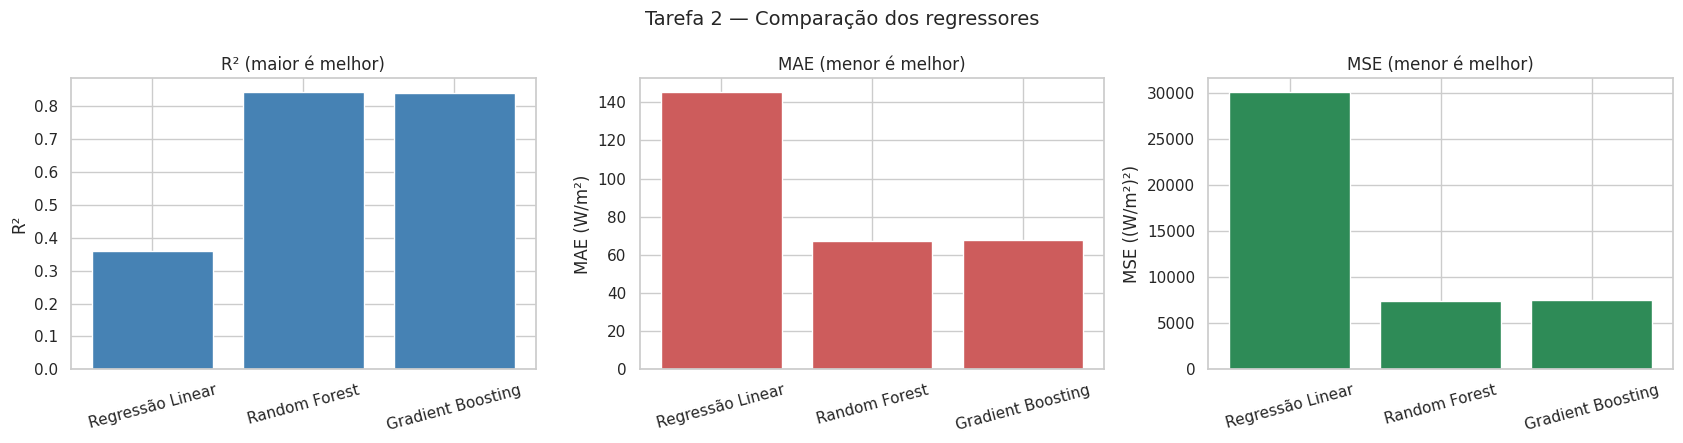

In [ ]:
# Métricas lado a lado
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
for ax, (col, cor, tit) in zip(axes, [("R²", "steelblue", "R² (maior é melhor)"),
                                       ("MAE (W/m²)", "indianred", "MAE (menor é melhor)"),
                                       ("MSE ((W/m²)²)", "seagreen", "MSE (menor é melhor)")]):
    ax.bar(comparacao_reg.index, comparacao_reg[col], color=cor)
    ax.set_title(tit); ax.set_ylabel(col)
    ax.tick_params(axis="x", rotation=15)
plt.suptitle("Tarefa 2 — Comparação dos regressores", fontsize=14)
plt.tight_layout()
plt.show()

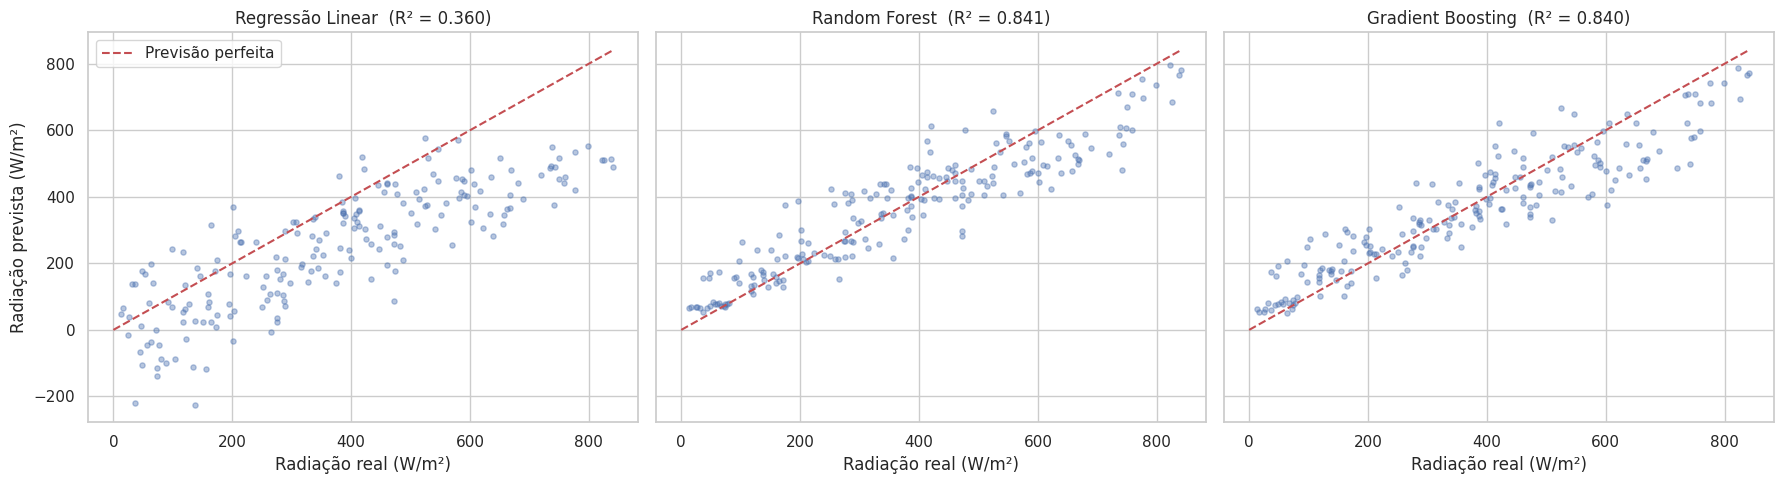

In [ ]:
# Gráfico real x previsto para os três modelos
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True, sharey=True)
limite = [0, max(y2_teste.max(), max(p.max() for p in previsoes_reg.values()))]
for ax, (nome, y_prev) in zip(axes, previsoes_reg.items()):
    ax.scatter(y2_teste, y_prev, alpha=0.4, s=14)
    ax.plot(limite, limite, "r--", label="Previsão perfeita")
    ax.set_title(f"{nome}  (R² = {comparacao_reg.loc[nome, 'R²']:.3f})")
    ax.set_xlabel("Radiação real (W/m²)")
axes[0].set_ylabel("Radiação prevista (W/m²)")
axes[0].legend()
plt.tight_layout()
plt.show()

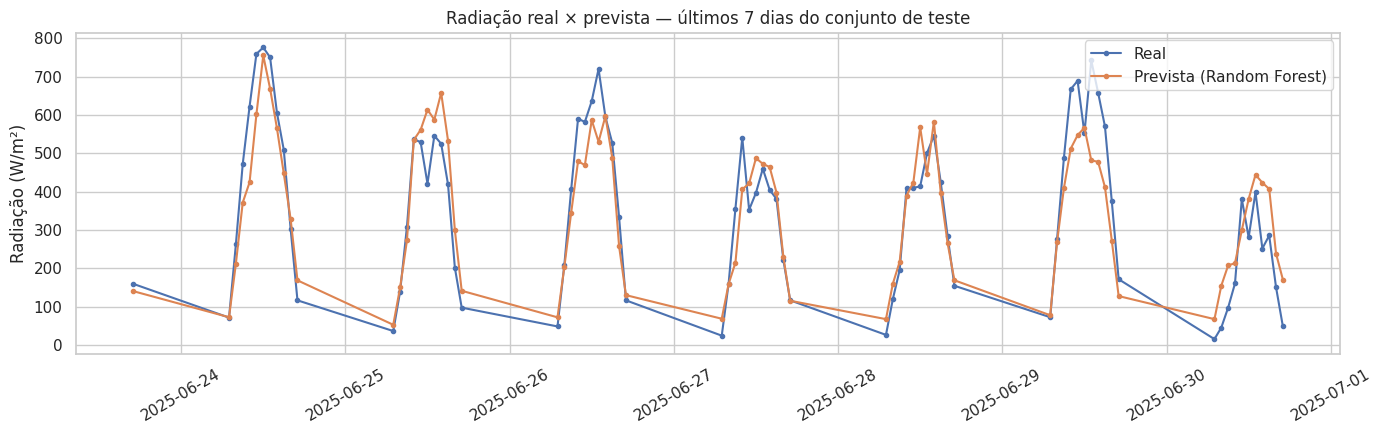

Melhor regressor (maior R²): Random Forest


In [ ]:
# Série temporal: real x previsto do melhor modelo (últimos 7 dias do teste)

# Converter a coluna para o formato de data
df2["data_hora"] = pd.to_datetime(df2["data_hora"])

melhor_reg = comparacao_reg["R²"].idxmax()

ultimos = df2.iloc[corte:].copy()
ultimos["prevista"] = previsoes_reg[melhor_reg]

# Selecionar os últimos 7 dias
ultimos = ultimos[
    ultimos["data_hora"] >= ultimos["data_hora"].max() - pd.Timedelta(days=7)
]

plt.figure(figsize=(14, 4.5))
plt.plot(ultimos["data_hora"], ultimos["radiacao_w_m2"],
         label="Real", marker=".")
plt.plot(ultimos["data_hora"], ultimos["prevista"],
         label=f"Prevista ({melhor_reg})", marker=".")

plt.title("Radiação real × prevista — últimos 7 dias do conjunto de teste")
plt.ylabel("Radiação (W/m²)")
plt.legend()
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

print("Melhor regressor (maior R²):", melhor_reg)

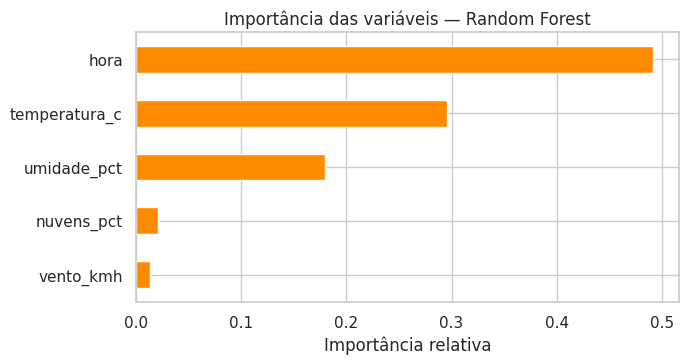

,Com hora,Sem hora
MAE (W/m²),67.1746,129.9794
R²,0.8408,0.3467


In [ ]:
# Importância das variáveis na Random Forest
rf = modelos_reg["Random Forest"]
importancia = pd.Series(rf.feature_importances_, index=X2.columns).sort_values()
importancia.plot(kind="barh", figsize=(7, 3.5), color="darkorange")
plt.title("Importância das variáveis — Random Forest")
plt.xlabel("Importância relativa")
plt.show()

# Retreinando SEM a hora
sem_hora = [c for c in X2.columns if c != "hora"]
rf_sem = RandomForestRegressor(n_estimators=200, min_samples_leaf=2, random_state=SEMENTE, n_jobs=-1)
rf_sem.fit(X2_treino[sem_hora], y2_treino)
prev_sem = rf_sem.predict(X2_teste[sem_hora])

teste_hora = pd.DataFrame({
    "Com hora":  [mean_absolute_error(y2_teste, previsoes_reg["Random Forest"]),
                  r2_score(y2_teste, previsoes_reg["Random Forest"])],
    "Sem hora":  [mean_absolute_error(y2_teste, prev_sem), r2_score(y2_teste, prev_sem)],
}, index=["MAE (W/m²)", "R²"]).round(4)
teste_hora

### 9. Interpretação — Tarefa 2

**Comparação dos modelos:** O melhor modelo é o que apresenta maior R² e menores MAE e MSE. Modelos de árvores podem representar melhor as variações da radiação solar do que a Regressão Linear.

**Onde estão os erros?** Os maiores desvios podem ocorrer em dias parcialmente nublados, devido às mudanças rápidas na radiação e às diferenças climáticas entre os períodos de treino e teste.

**Importância da hora:** A hora influencia a posição do sol, mas temperatura e umidade podem fornecer informações semelhantes. Se o erro aumentar sem essa variável, ela tem maior importância para a previsão.

**Por que radiação prevista não é igual à energia produzida?** Porque a radiação é medida em W/m², enquanto a energia depende do tempo, da área e da eficiência dos painéis. Inclinação, temperatura, sombreamento e perdas do sistema também afetam a geração. Além disso, os dados cobrem apenas o período diurno de três meses, não o ano inteiro.

# Entrega pelo GitHub

Envie **apenas o link do repositório público**. Organize-o com:

- `README.md` contendo objetivo, fontes e período dos dados, instruções para executar o notebook e resumo dos resultados;
- notebook `.ipynb` com a consulta às APIs, sua análise, os **três classificadores e os três regressores**, todos os imports necessários adicionados por você e conclusões em Markdown;
- os dois CSVs gerados (ou instruções completas e testadas para reproduzi-los) e eventuais figuras utilizadas.

Verifique se o notebook roda **na ordem das células** a partir de um ambiente limpo. Não inclua senhas, tokens ou arquivos sem relação com a avaliação. A banca deve conseguir encontrar as seis comparações e as respostas às duas tarefas sem procurar uma agulha no palheiro.

### Fontes

- [ANEEL — SIGA](https://dadosabertos.aneel.gov.br/dataset/siga-sistema-de-informacoes-de-geracao-da-aneel)
- [ANEEL — recurso e campos usados](https://dadosabertos.aneel.gov.br/dataset/siga-sistema-de-informacoes-de-geracao-da-aneel/resource/11ec447d-698d-4ab8-977f-b424d5deee6a)
- [Open-Meteo — histórico e unidades](https://open-meteo.com/en/docs/historical-weather-api)